In [1]:
from fastai.vision.all import *
# from sklearn.metrics import roc_curve, auc
# from fastai.metrics import * 

# from pathlib import Path
from sklearn.model_selection import  train_test_split # GroupKFold, StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut,
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')
import numpy as np
from numpy import random
import shutil
import glob
import os

In [2]:
# Create some regular expression queries:
path = Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6')
# (path/"summary").ls()
use='summary'
fname = (path/use).ls()[0]
print(fname.name)
re_class= r"class_(.+)_x\d+_y\d+.jpg"
out=re.findall(re_class,fname.name)
print(out)
re_slide =r'(.+)_class_\S+_x\d+_y\d+.jpg$'
out=re.findall(re_slide,fname.name)
print(out)
re_slide_class=r'(.+)_class_(.+)_x\d+_y\d+.jpg$'
slides=[]
slides_c=[]
all_c=[]
all_f=[]
for f in (path/use).ls():
    all_f.append(f.name)
    slide, c = re.findall(re_slide_class,f.name)[0]
    slides_c.append("%s_%s" % (slide,c))
    slides.append(slide)
    all_c.append(c)
print(np.unique(slides_c), len(np.unique(slides_c)))
posf = np.array([(f,c,s) for f,c,s in zip(all_f,all_c,slides) if c =='pos'])
negf = np.array([(f,c,s) for f,c,s in zip(all_f,all_c,slides) if c =='neg'])


1007731_class_pos_x3750_y7500.jpg
['pos']
['1007731']
['1007466_neg' '1007467_neg' '1007468_neg' '1007469_neg' '1007470_neg'
 '1007471_neg' '1007473_neg' '1007474_neg' '1007476_pos' '1007477_pos'
 '1007478_pos' '1007482_pos' '1007484_pos' '1007485_pos' '1007486_pos'
 '1007720_neg' '1007731_pos' '1007733_pos' '1007820_neg' '1007821_neg'
 '1007822_neg' '1007824_neg' '1007825_neg' '1007826_pos' '1007827_pos'
 '1007828_pos' '1007829_pos' '1007830_pos' '1007831_pos' '1007832_pos'
 '1007845_neg' '1007846_neg' '1007847_neg' '1007848_neg'] 34


In [14]:
#Check that all .svs files actually result in tiles being extracted:
path_raw_pos = path.parent.parent.joinpath('raw').joinpath('bile_ducts_pos')
path_raw_neg = path.parent.parent.joinpath('raw').joinpath('bile_ducts_neg')
all_svs = path_raw_pos.ls() + path_raw_neg.ls()
# print(all_svs)
re_raw_class=r'(+.).svs$'
missing = 0
for raw in all_svs:
    r_id = raw.parts[-1].split('.')[0]
    if r_id not in slides:
        if 'pos' in str(raw):
            c='pos'
        else:
            c='neg'
        print('%s %s not found in processed tiles!' % (r_id,c))
        missing +=1
if missing == 0:
    print('All %d .svs files have processed tiles.' % (len(all_svs)))
        

1007726 neg not found in processed tiles!


In [7]:
# df = pd.read_csv(path.joinpath('summary_model/resnet18_jackknife_v0/csv/').joinpath('train_valid_fold_0.csv'))
df = pd.read_csv(path.joinpath('tiles_model/resnet18_jackknife_v0/csv/').joinpath('train_valid_fold_0.csv'))
df.head()

,Unnamed: 0,fn,slide,class,is_valid,full_path
0,0,1007468_class_neg_x9750_y53750.jpg,1007468,neg,0,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007468_class_neg_x9750_y53750.jpg
1,1,1007821_class_neg_x21250_y6500.jpg,1007821,neg,0,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007821_class_neg_x21250_y6500.jpg
2,2,1007847_class_neg_x40250_y6750.jpg,1007847,neg,0,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007847_class_neg_x40250_y6750.jpg
3,3,1007847_class_neg_x39250_y89250.jpg,1007847,neg,0,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007847_class_neg_x39250_y89250.jpg
4,4,1007822_class_neg_x11250_y104750.jpg,1007822,neg,0,/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/data/biliseq_he_class/proc/v6/tiles/1007822_class_neg_x11250_y104750.jpg


In [8]:
#Check data loader:
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_x=ColReader('full_path'),
                  splitter=ColSplitter('is_valid') ,# GrandparentSplitter(train_name='train',valid_name='valid'),
                  get_y=  ColReader('class'), #using_attr(RegexLabeller(re_class), 'name'),
                  item_tfms=Resize(460),
                  batch_tfms=aug_transforms(size=224,
                                            max_rotate=45,
                                            min_scale=0.75,
                                            flip_vert=True,
                                           )
                 )
dls = tissue.dataloaders(df, bs = 128)
                  

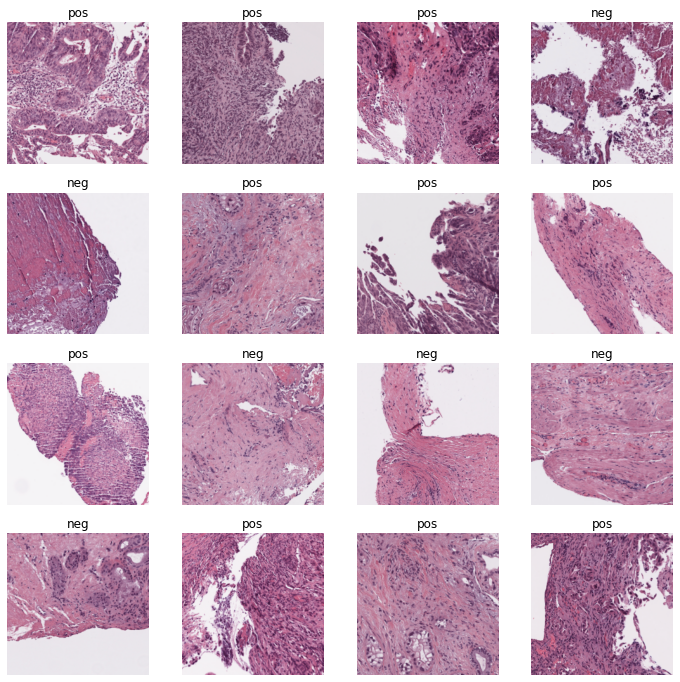

In [6]:
dls.train.show_batch(max_n=16,nrows=4)

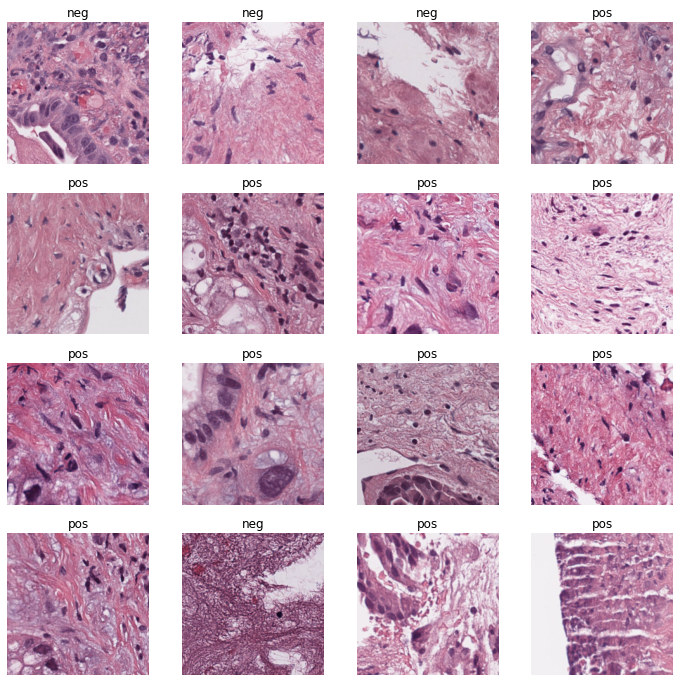

In [9]:
dls.train.show_batch(max_n=16,nrows=4)

In [24]:
#Fit 10 resnet18 models to full dataset

# export_path=path.joinpath('model/resnet18_10kfold/fold_models')
export_path = path.joinpath('%s_model' % use).joinpath('resnet18_10kfold/fold_models')
if export_path.exists()==False:
    os.makedirs(export_path)
for seed in range(0,1):
    print('Fold :', seed)
    df=pd.read_csv(csv_path.joinpath('train_valid_fold_%d.csv' % seed))
    tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                      get_x=ColReader('full_path'),
                      splitter=ColSplitter('is_valid') ,# GrandparentSplitter(train_name='train',valid_name='valid'),
                      get_y=  ColReader('class'), #using_attr(RegexLabeller(re_class), 'name'),
                      item_tfms=Resize(460),
                      batch_tfms=aug_transforms(size=224,
                                                max_rotate=45,
                                                min_scale=0.75,
                                                flip_vert=True,
                                               )
                                 ) 
    dls = tissue.dataloaders(df, bs = 128)
    learn = cnn_learner(dls, resnet18,
                    metrics=[error_rate, accuracy],
                    ).to_fp16()

    learn.fine_tune(5,freeze_epochs=1)
    # learn.export(fname=export_path.joinpath('resnet18_1_5_%d.pkl' % seed))
    
    # learn = cnn_learner(dls, xresnet50,
    #                 metrics=[error_rate, accuracy],
    #                 ).to_fp16()
    # learn.fine_tune(5,freeze_epochs=2)
    # learn.export(fname=export_path.joinpath('xresnet50_2_5_%d.pkl' % seed))

Fold : 0


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.227366,0.942136,0.437063,0.562937,03:51


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.866780,0.830618,0.395105,0.604895,03:44
1,0.817584,0.832209,0.381119,0.618881,03:48
2,0.726224,0.927704,0.381119,0.618881,03:50
3,0.673941,0.959753,0.377622,0.622378,03:45
4,0.626096,0.971711,0.381119,0.618881,03:44


In [237]:
# Examine test inference:
u_slides_c=np.unique(slides_c)
temp = [item.split('_') for item in u_slides_c]
fold_df=pd.DataFrame(temp,columns=['slide','class'])
s=time.time()
export_path=path.joinpath('model/resnet18_10kfold/fold_models')
dev=2
for seed in range(0,10):
    print('Fold :', seed)
    df=pd.read_csv(path.joinpath('model').joinpath('resnet18_10kfold/csv').joinpath('train_valid_fold_%d.csv' % seed))
    model_fn=export_path.joinpath('resnet18_1_5_%d.pkl' % seed)
    learn = load_learner(model_fn)
    test_df=df.loc[df.loc[:,'is_valid']==1,:].reset_index()
    dl = learn.dls.test_dl(test_df.loc[:,'full_path'],
                          ) #device='cuda:2' #Does not work
    pred = learn.get_preds(dl=dl,with_decoded=True)
    
    test_slides=np.unique(test_df.loc[:,'slide'])
    p=np.array(pred[0]) # Probability ['neg','pos'] (Can check with dls.vocab )
    c=np.array(pred[2]) #Predictions decoded
    fold_df['p1_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    fold_df['wta_fold_%d' % seed] = np.zeros((fold_df.shape[0],1))*np.nan
    for slide in test_slides:
        src_idx = np.array(test_df.loc[:,'slide']) == slide
        p1 = np.mean(p[src_idx,1])
        if np.sum(c[src_idx]==0) > np.sum(c[src_idx]==1):
            wta=0
        else:
            wta=1
        dest_idx = np.array(fold_df.loc[:,'slide'])== str(slide)
        # print(dest_idx,p1)
        fold_df.loc[dest_idx,'p1_fold_%d' % seed] = p1
        fold_df.loc[dest_idx,'wta_fold_%d' % seed] = wta
ss=time.time()
print('Wall time: %ds' % (ss-s))
fold_df.head()
# fold_df.to_csv(export_path.parent.joinpath('fold_summary.csv'))

Fold : 0


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [221]:
fold_df.to_csv(export_path.parent.joinpath('fold_summary.csv'))

[0.52992213 0.21072223 0.306874   0.19390796 0.70529312 0.10043073
 0.59939089 0.34244689 0.3798006  0.40377624 0.60211077 0.38657179
 0.75506413 0.60354442 0.66276437 0.25359228 0.15629013 0.53104091
 0.84262857 0.54222639 0.29825913 0.52303231        nan 0.60760242
 0.45737192 0.5906198  0.29903647 0.68806225 0.72970636 0.37020445
        nan 0.20438273 0.59467373 0.67846382 0.39325027]
[1. 0. 0. 0. 1. 0. 3. 0. 0. 0. 4. 0. 2. 2. 4. 0. 0. 4. 2. 3. 0. 2. 0. 2.
 0. 1. 0. 3. 4. 0. 0. 0. 3. 1. 0.]
0.6060606060606061
[[10  8]
 [ 5 10]]


<ipython-input-238-54578283b019>:9: RuntimeWarning: Mean of empty slice
  print(np.nanmean(p1,axis=1))
<ipython-input-238-54578283b019>:14: RuntimeWarning: All-NaN slice encountered
  m_p1=np.nanmax(p1,axis=1)


Text(0.5, 1.0, 'AUROC 0.741, Sensitivity: 0.67, Specificity: 0.56')

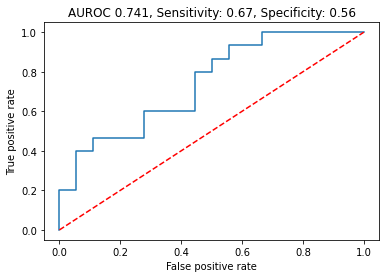

In [238]:
fold_df=pd.read_csv(export_path.parent.joinpath('fold_summary.csv'))
p1=[]
wta=[]
for fold in range(0,10):
    p1.append(np.array(fold_df.loc[:,'p1_fold_%d' % fold]))
    wta.append(np.array(fold_df.loc[:,'wta_fold_%d' % fold]))
p1=np.array(p1).transpose()
wta=np.array(wta).transpose()
print(np.nanmean(p1,axis=1))
print(np.nansum(wta,axis=1))
# pred_pos = np.nansum(wta,axis=1)>0 

true_pos = np.array(fold_df.loc[:,'class'])=='pos'
m_p1=np.nanmax(p1,axis=1)

use = ~np.isnan(m_p1)
# sum(exc)
print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
pred_pos = m_p1 > 0.5
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

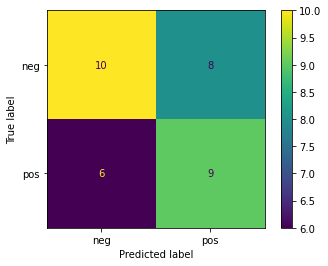

In [243]:
wta_tot=np.nansum(wta,axis=1) > 0
cc=skm.confusion_matrix(true_pos[use],wta_tot[use])
skm.ConfusionMatrixDisplay.from_predictions(true_pos[use],wta_tot[use],
                                            display_labels=learn.dls.vocab)